In [1]:
import torch as th
import numpy as np
import torch.nn as nn
import torch.optim as opt
import matplotlib.pyplot as plt
import scipy.io as sio
import time
import os
import pandas as pd
import scipy.signal as scs
from tqdm import tqdm
import seaborn as sns

import sys
sys.path.append('..')

from models.networks import SoftSensingLSTM, SoftSensingLSTMCNN
import aux_plot
from aux_data import get_dataset_dict, exponential_moving_average

data_dir_path = '../data/SoftTex/'

In [4]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

In [5]:
dataset_names = ['dataset_res_sens_pos_1.mat', 
                 'dataset_res_sens_pos_2.mat', 
                 'dataset_res_sens_pos_3.mat']

dataset_dict = get_dataset_dict(data_dir_path=data_dir_path, dataset_names=dataset_names)

print(dataset_dict.keys())
print(dataset_dict[list(dataset_dict.keys())[0]].keys())

# load pressure datasets
pressure_dataset_names = ['dataset_act_sens_pos_1.mat', 
                          'dataset_act_sens_pos_2.mat', 
                          'dataset_act_sens_pos_3.mat']

for dataset_name, pressure_dataset_name in zip(dataset_names, pressure_dataset_names):
    dataset = sio.loadmat(data_dir_path + pressure_dataset_name)['Dataset']
    pressures = dataset[:, [0,1,2]]

    dataset_dict[dataset_name]['pressure'] = pressures

print(dataset_dict.keys())
print(dataset_dict[list(dataset_dict.keys())[0]].keys())

dict_keys(['dataset_res_sens_pos_1.mat', 'dataset_res_sens_pos_2.mat', 'dataset_res_sens_pos_3.mat'])
dict_keys(['sensor_voltage', 'sensor_resistance', 'tip_position'])
dict_keys(['dataset_res_sens_pos_1.mat', 'dataset_res_sens_pos_2.mat', 'dataset_res_sens_pos_3.mat'])
dict_keys(['sensor_voltage', 'sensor_resistance', 'tip_position', 'pressure'])


In [6]:
for i in range(3):
    pressures = dataset_dict['dataset_res_sens_pos_%d.mat' % (i+1)]['pressure']
    sensor = dataset_dict['dataset_res_sens_pos_%d.mat' % (i+1)]['sensor_resistance']
    tip_position = dataset_dict['dataset_res_sens_pos_%d.mat' % (i+1)]['tip_position']

    print(i+1)
    print(pressures.shape[0])
    print(np.mean(pressures, axis=0).round(2), np.min(pressures, axis=0), np.max(pressures, axis=0))
    print(np.mean(sensor, axis=0).round(2), np.min(sensor, axis=0).round(2), np.max(sensor, axis=0).round(2))
    print(np.mean(tip_position, axis=0).round(2), np.min(tip_position, axis=0).round(2), np.max(tip_position, axis=0).round(2))

1
10801
[12.5 12.5 12.5] [0. 0. 0.] [75. 75. 75.]
[13.49 15.02 14.65] [ 9.74 11.38 11.03] [20.05 22.12 20.94]
[ 404.98  -58.57 -237.  ] [ 359.06  -82.21 -250.9 ] [ 438.66  -15.36 -213.7 ]
2
5401
[12.5 12.5 12.5] [0. 0. 0.] [75. 75. 75.]
[13.84 14.45 14.79] [ 9.96 10.75 10.89] [19.78 21.29 20.52]
[ 407.73  -58.75 -236.26] [ 363.04  -82.71 -251.89] [ 439.05  -15.68 -212.94]
3
16201
[12.5 12.5 12.5] [0. 0. 0.] [75. 75. 75.]
[13.53 14.29 14.45] [ 9.77 10.68 10.72] [20.25 21.59 21.02]
[ 408.09  -58.78 -235.8 ] [ 361.78  -83.61 -252.12] [ 440.03  -14.1  -210.98]


In [6]:
pressures = dataset_dict['dataset_res_sens_pos_1.mat']['pressure']
sensor = dataset_dict['dataset_res_sens_pos_1.mat']['sensor_resistance']
tip_position = dataset_dict['dataset_res_sens_pos_1.mat']['tip_position']

from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler = StandardScaler()
#scaler = MinMaxScaler(feature_range=(-1,1))

#pressures = scaler.fit_transform(pressures)
sensor = scaler.fit_transform(sensor)
#tip_position = scaler.fit_transform(tip_position)

#null_scaled_pressure = scaler.transform(np.zeros_like(pressures))
#null_scaled_voltage = scaler.transform(np.zeros_like(sensor_voltage))

#null_scaled_voltage, scaler.mean_, scaler.var_


In [85]:
th.tensor(np.random.uniform(-0.5,0.5, (16,3))).shape

torch.Size([16, 3])

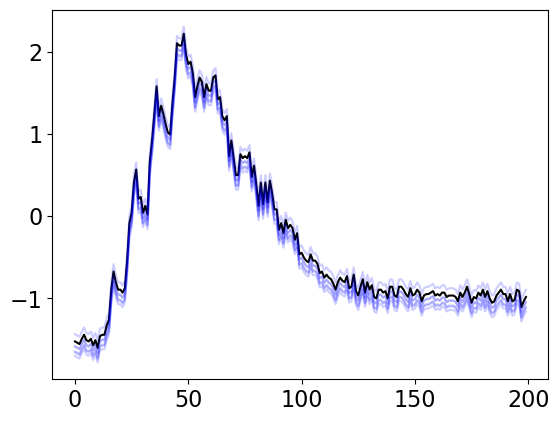

In [93]:
plt.plot(sensor[:200, 0], color='black')
plt.plot(sensor[:200, 0] + np.random.uniform(-0.2, 0.2), color='blue', alpha=0.2)
plt.plot(sensor[:200, 0] + np.random.uniform(-0.2, 0.2), color='blue', alpha=0.2)
plt.plot(sensor[:200, 0] + np.random.uniform(-0.2, 0.2), color='blue', alpha=0.2)
plt.plot(sensor[:200, 0] + np.random.uniform(-0.2, 0.2), color='blue', alpha=0.2)
plt.plot(sensor[:200, 0] + np.random.uniform(-0.2, 0.2), color='blue', alpha=0.2)
plt.plot(sensor[:200, 0] + np.random.uniform(-0.2, 0.2), color='blue', alpha=0.2)


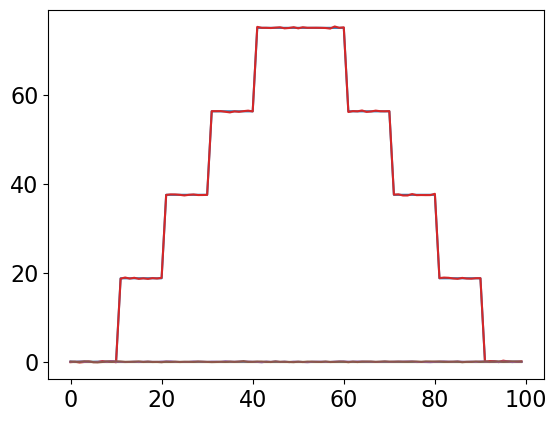

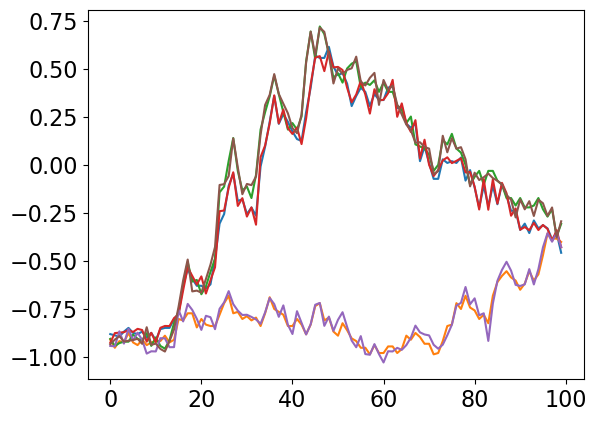

In [22]:
plt.plot(pressures[:100])
plt.plot(pressures[:100] + np.random.normal(0,(1e-1, 5e-2, 5e-2), (100,3)))
plt.show()

plt.plot(sensor[:100])
plt.plot(sensor[:100] + np.random.normal(0,3e-2, (100,3)))

#plt.plot(tip_position[:100,0])
#plt.plot(tip_position[:100,0] + np.random.normal(0,2e-2, (100)))

In [81]:
np.random.normal(0, (1e-1, 1e-1, 1e-1), (200,3))

array([[ 5.42026142e-02,  3.14959123e-02,  2.79658597e-02],
       [-2.69089820e-02, -1.67459246e-01,  9.83500778e-02],
       [-5.52813700e-02, -1.10040727e-03, -1.96129791e-01],
       [ 6.04270091e-02, -7.35265180e-02, -2.21309539e-02],
       [-1.21653264e-01,  1.05195146e-01, -3.09696383e-02],
       [ 1.41507124e-02,  3.70137807e-02, -4.73785734e-02],
       [ 3.25369860e-01, -1.06237219e-01, -8.14054635e-02],
       [ 1.28532966e-01,  4.37931201e-02, -6.40589075e-02],
       [-7.14763430e-02,  1.87445317e-02, -2.08245329e-01],
       [-4.76520528e-02, -1.01614346e-02,  2.52871983e-02],
       [-9.39334268e-02, -4.07005412e-02,  1.04385805e-02],
       [-1.31990945e-01, -1.01218290e-01,  5.26797938e-02],
       [ 1.56465660e-01,  1.60515308e-01, -3.19177486e-02],
       [ 1.12234716e-01,  2.73294486e-02, -9.79687174e-02],
       [-5.98051575e-03, -7.50040764e-02,  5.98702215e-02],
       [ 4.27276645e-02, -2.81576260e-02, -1.39601995e-01],
       [ 7.13315256e-02, -8.50428859e-02

In [32]:
pressures_1 = dataset_dict['dataset_res_sens_pos_1.mat']['pressure']
pressures_2 = dataset_dict['dataset_res_sens_pos_2.mat']['pressure']
pressures_3 = dataset_dict['dataset_res_sens_pos_3.mat']['pressure']

sampling_frequency = 50 # Hz
n_samples_1 = pressures_1.shape[0]
n_samples_2 = pressures_2.shape[0]
n_samples_3 = pressures_3.shape[0]

total_time_1 = n_samples_1 / sampling_frequency
total_time_2 = n_samples_2 / sampling_frequency
total_time_3 = n_samples_3 / sampling_frequency

t_1 = np.linspace(0, total_time_1, n_samples_1)
t_2 = np.linspace(0, total_time_2, n_samples_2)
t_3 = np.linspace(0, total_time_3, n_samples_3)

np.unique(np.round(pressures_1[:,0],1)), np.unique(np.round(pressures_2[:,0],1))

(array([ 0. ,  5.4,  8.3, 10.7, 16.1, 16.7, 18.8, 21.4, 25. , 26.8, 32.1,
        33.3, 37.5, 41.7, 42.9, 48.2, 50. , 53.6, 56.2, 58.3, 58.9, 64.3,
        66.7, 69.6, 75. ]),
 array([ 0. ,  5.4,  8.3, 10.7, 16.1, 16.7, 18.8, 21.4, 25. , 26.8, 32.1,
        33.3, 37.5, 41.7, 42.9, 48.2, 50. , 53.6, 56.2, 58.3, 58.9, 64.3,
        66.7, 69.6, 75. ]))

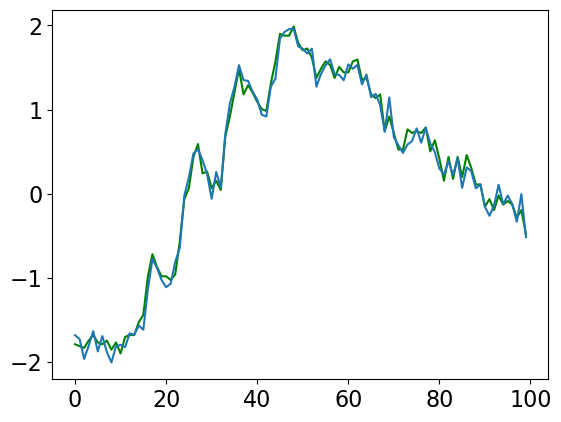

In [72]:
voltage_1 = dataset_dict['dataset_res_sens_pos_1.mat']['sensor_voltage']
voltage_2 = dataset_dict['dataset_res_sens_pos_2.mat']['sensor_voltage']

from sklearn.preprocessing import MinMaxScaler, StandardScaler

observation_scaler = StandardScaler() # MinMaxScaler(feature_range=(0,1))
observation_scaler.fit(np.concatenate((voltage_1, voltage_2)))

voltage_1 = observation_scaler.transform(voltage_1)
voltage_1_noise = np.random.normal(0, scale=1e-1, size=voltage_1.shape)

#mov_average = np.zeros_like(voltage_1)
#mov_average[0] = voltage_1[0]
#for i in range(1, mov_average.shape[0]):
#    mov_average[i] = 0.2 * voltage_1[i] + (1 - 0.2) * mov_average[i] 

plt.plot(voltage_1[:100, 0], color='green')
#plt.plot(mov_average[:100, 0], color='red')
plt.plot(voltage_1[:100, 0] + voltage_1_noise[:100,0])

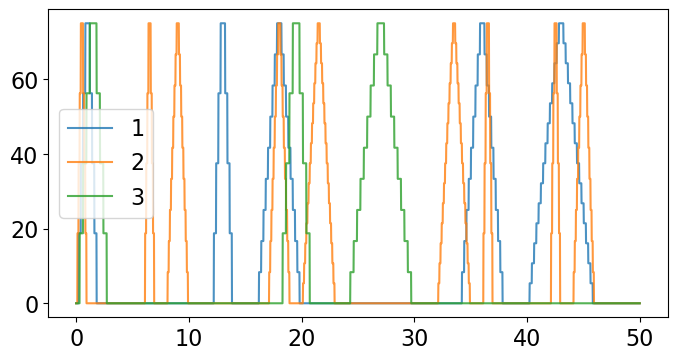

In [42]:
plt.figure(figsize=(8,4))
plt.plot(t_1[:2500], pressures_1[:2500, 0], alpha=0.8, label='1')
plt.plot(t_2[:2500], pressures_2[:2500, 0], alpha=0.8, label='2')
plt.plot(t_3[:2500], pressures_3[:2500, 0], alpha=0.8, label='3')
plt.legend()

[ 0.   8.3  8.3 16.7 16.7 18.8 25.  33.3 33.3 37.5 41.7 41.7 50.  56.2
 58.3 58.3 66.7 75. ]


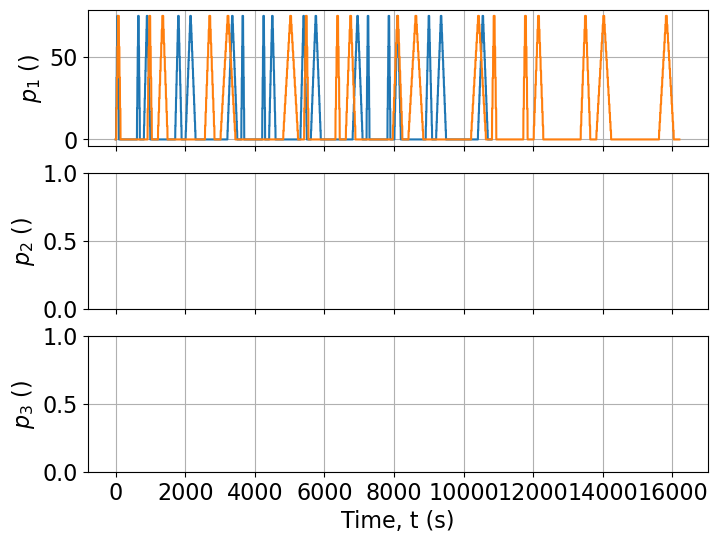

In [27]:
n_samples = pressures.shape[0]
sampling_frequency = 50 # Hz
total_time = n_samples / sampling_frequency
t = np.linspace(0, total_time, num=n_samples)

# visualize actuations
fig, (ax1, ax2, ax3) =  plt.subplots(figsize=(8,6), nrows=3, ncols=1, sharex=True, dpi=100)
#ax1.plot(t, pressures[:,0], linewidth=2)
#ax2.plot(t, pressures[:,1], linewidth=2)
#ax3.plot(t, pressures[:,2], linewidth=2)
plt.xlabel('Time, t (s)')
ax1.set_ylabel('$p_1$ ()')
ax2.set_ylabel('$p_2$ ()')
ax3.set_ylabel('$p_3$ ()')
ax1.grid(); ax2.grid(); ax3.grid()

print(np.round(np.unique(pressures[:1500,0]),1))
#np.linspace(0,75, 5), 

In [5]:
import seaborn as sns

data_dir_path = '../data/SoftTex/'
dataset_names = ['dataset_res_sens_pos_1.mat', 'dataset_res_sens_pos_2.mat', 'dataset_res_sens_pos_3.mat']

dataset_dict = get_dataset_dict(data_dir_path=data_dir_path, dataset_names=dataset_names)

# Concatenate pressure dataset
pressure_dataset_names = ['dataset_act_sens_pos_1.mat', 
                          'dataset_act_sens_pos_2.mat', 
                          'dataset_act_sens_pos_3.mat']

for dataset_name, pressure_dataset_name in zip(dataset_names, pressure_dataset_names):
    dataset = sio.loadmat(data_dir_path + pressure_dataset_name)['Dataset']
    pressures = dataset[:, [0,1,2]]

    dataset_dict[dataset_name]['pressure'] = pressures


TR_idx, VL_idx, TS_idx = 3, 1, 2

tr_pressure = dataset_dict['dataset_res_sens_pos_%d.mat' % TR_idx]['pressure']
tr_sensor = dataset_dict['dataset_res_sens_pos_%d.mat' % TR_idx]['sensor_resistance']
tr_tip_position = dataset_dict['dataset_res_sens_pos_%d.mat' % TR_idx]['tip_position']

vl_pressure = dataset_dict['dataset_res_sens_pos_%d.mat' % VL_idx]['pressure']
vl_sensor = dataset_dict['dataset_res_sens_pos_%d.mat' % VL_idx]['sensor_resistance']
vl_tip_position = dataset_dict['dataset_res_sens_pos_%d.mat' % VL_idx]['tip_position']

ts_pressure = dataset_dict['dataset_res_sens_pos_%d.mat' % TS_idx]['pressure']
ts_sensor = dataset_dict['dataset_res_sens_pos_%d.mat' % TS_idx]['sensor_resistance']
ts_tip_position = dataset_dict['dataset_res_sens_pos_%d.mat' % TS_idx]['tip_position']

In [4]:
tr_pressure.shape, vl_pressure.shape

((16201, 3), (10801, 3))

In [48]:
name_to_curve_color = {'Training set': sns.palettes.SEABORN_PALETTES['dark'][2],
                       'Validation set': sns.palettes.SEABORN_PALETTES['dark'][0],
                       'Test set': sns.palettes.SEABORN_PALETTES['dark'][1]
                       }

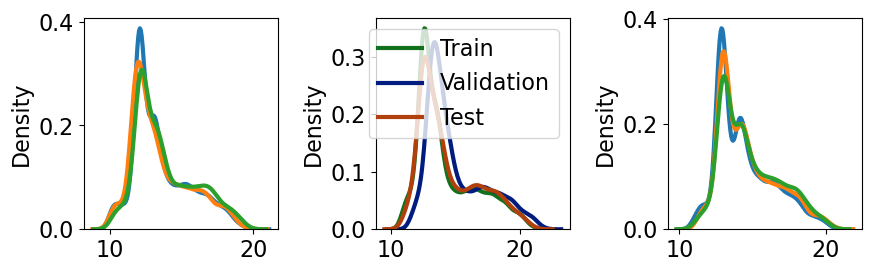

In [60]:
fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(9,3))

sns.kdeplot(ax=axes[0], data=tr_sensor[:,0], linewidth=3, label='train')
sns.kdeplot(ax=axes[0], data=vl_sensor[:,0], linewidth=3, label='validation')
sns.kdeplot(ax=axes[0], data=ts_sensor[:,0], linewidth=3, label='test')

sns.kdeplot(ax=axes[1], data=tr_sensor[:,1], color=name_to_curve_color['Training set'], linewidth=3, label='Train')
sns.kdeplot(ax=axes[1], data=vl_sensor[:,1], color=name_to_curve_color['Validation set'], linewidth=3, label='Validation')
sns.kdeplot(ax=axes[1], data=ts_sensor[:,1], color=name_to_curve_color['Test set'], linewidth=3, label='Test')

sns.kdeplot(ax=axes[2], data=tr_sensor[:,2], linewidth=3, label='Train')
sns.kdeplot(ax=axes[2], data=vl_sensor[:,2], linewidth=3, label='Validation')
sns.kdeplot(ax=axes[2], data=ts_sensor[:,2], linewidth=3, label='Test')

axes[1].legend(loc='best')
plt.tight_layout()

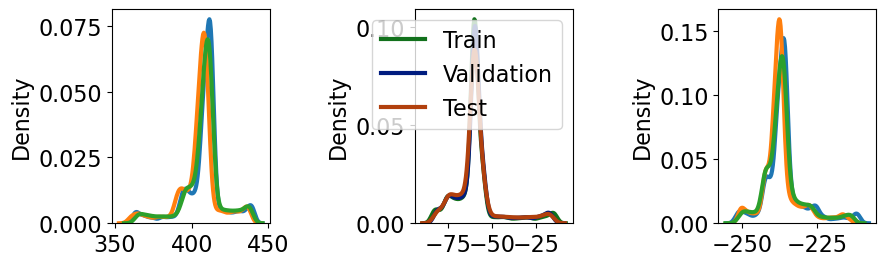

In [61]:
fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(9,3))

sns.kdeplot(ax=axes[0], data=tr_tip_position[:,0], linewidth=3, label='train')
sns.kdeplot(ax=axes[0], data=vl_tip_position[:,0], linewidth=3, label='validation')
sns.kdeplot(ax=axes[0], data=ts_tip_position[:,0], linewidth=3, label='test')

sns.kdeplot(ax=axes[1], data=tr_tip_position[:,1], color=name_to_curve_color['Training set'], linewidth=3, label='Train')
sns.kdeplot(ax=axes[1], data=vl_tip_position[:,1], color=name_to_curve_color['Validation set'], linewidth=3, label='Validation')
sns.kdeplot(ax=axes[1], data=ts_tip_position[:,1], color=name_to_curve_color['Test set'], linewidth=3, label='Test')

sns.kdeplot(ax=axes[2], data=tr_tip_position[:,2], linewidth=3, label='Train')
sns.kdeplot(ax=axes[2], data=vl_tip_position[:,2], linewidth=3, label='Validation')
sns.kdeplot(ax=axes[2], data=ts_tip_position[:,2], linewidth=3, label='Test')

axes[1].legend(loc='best')
plt.tight_layout()

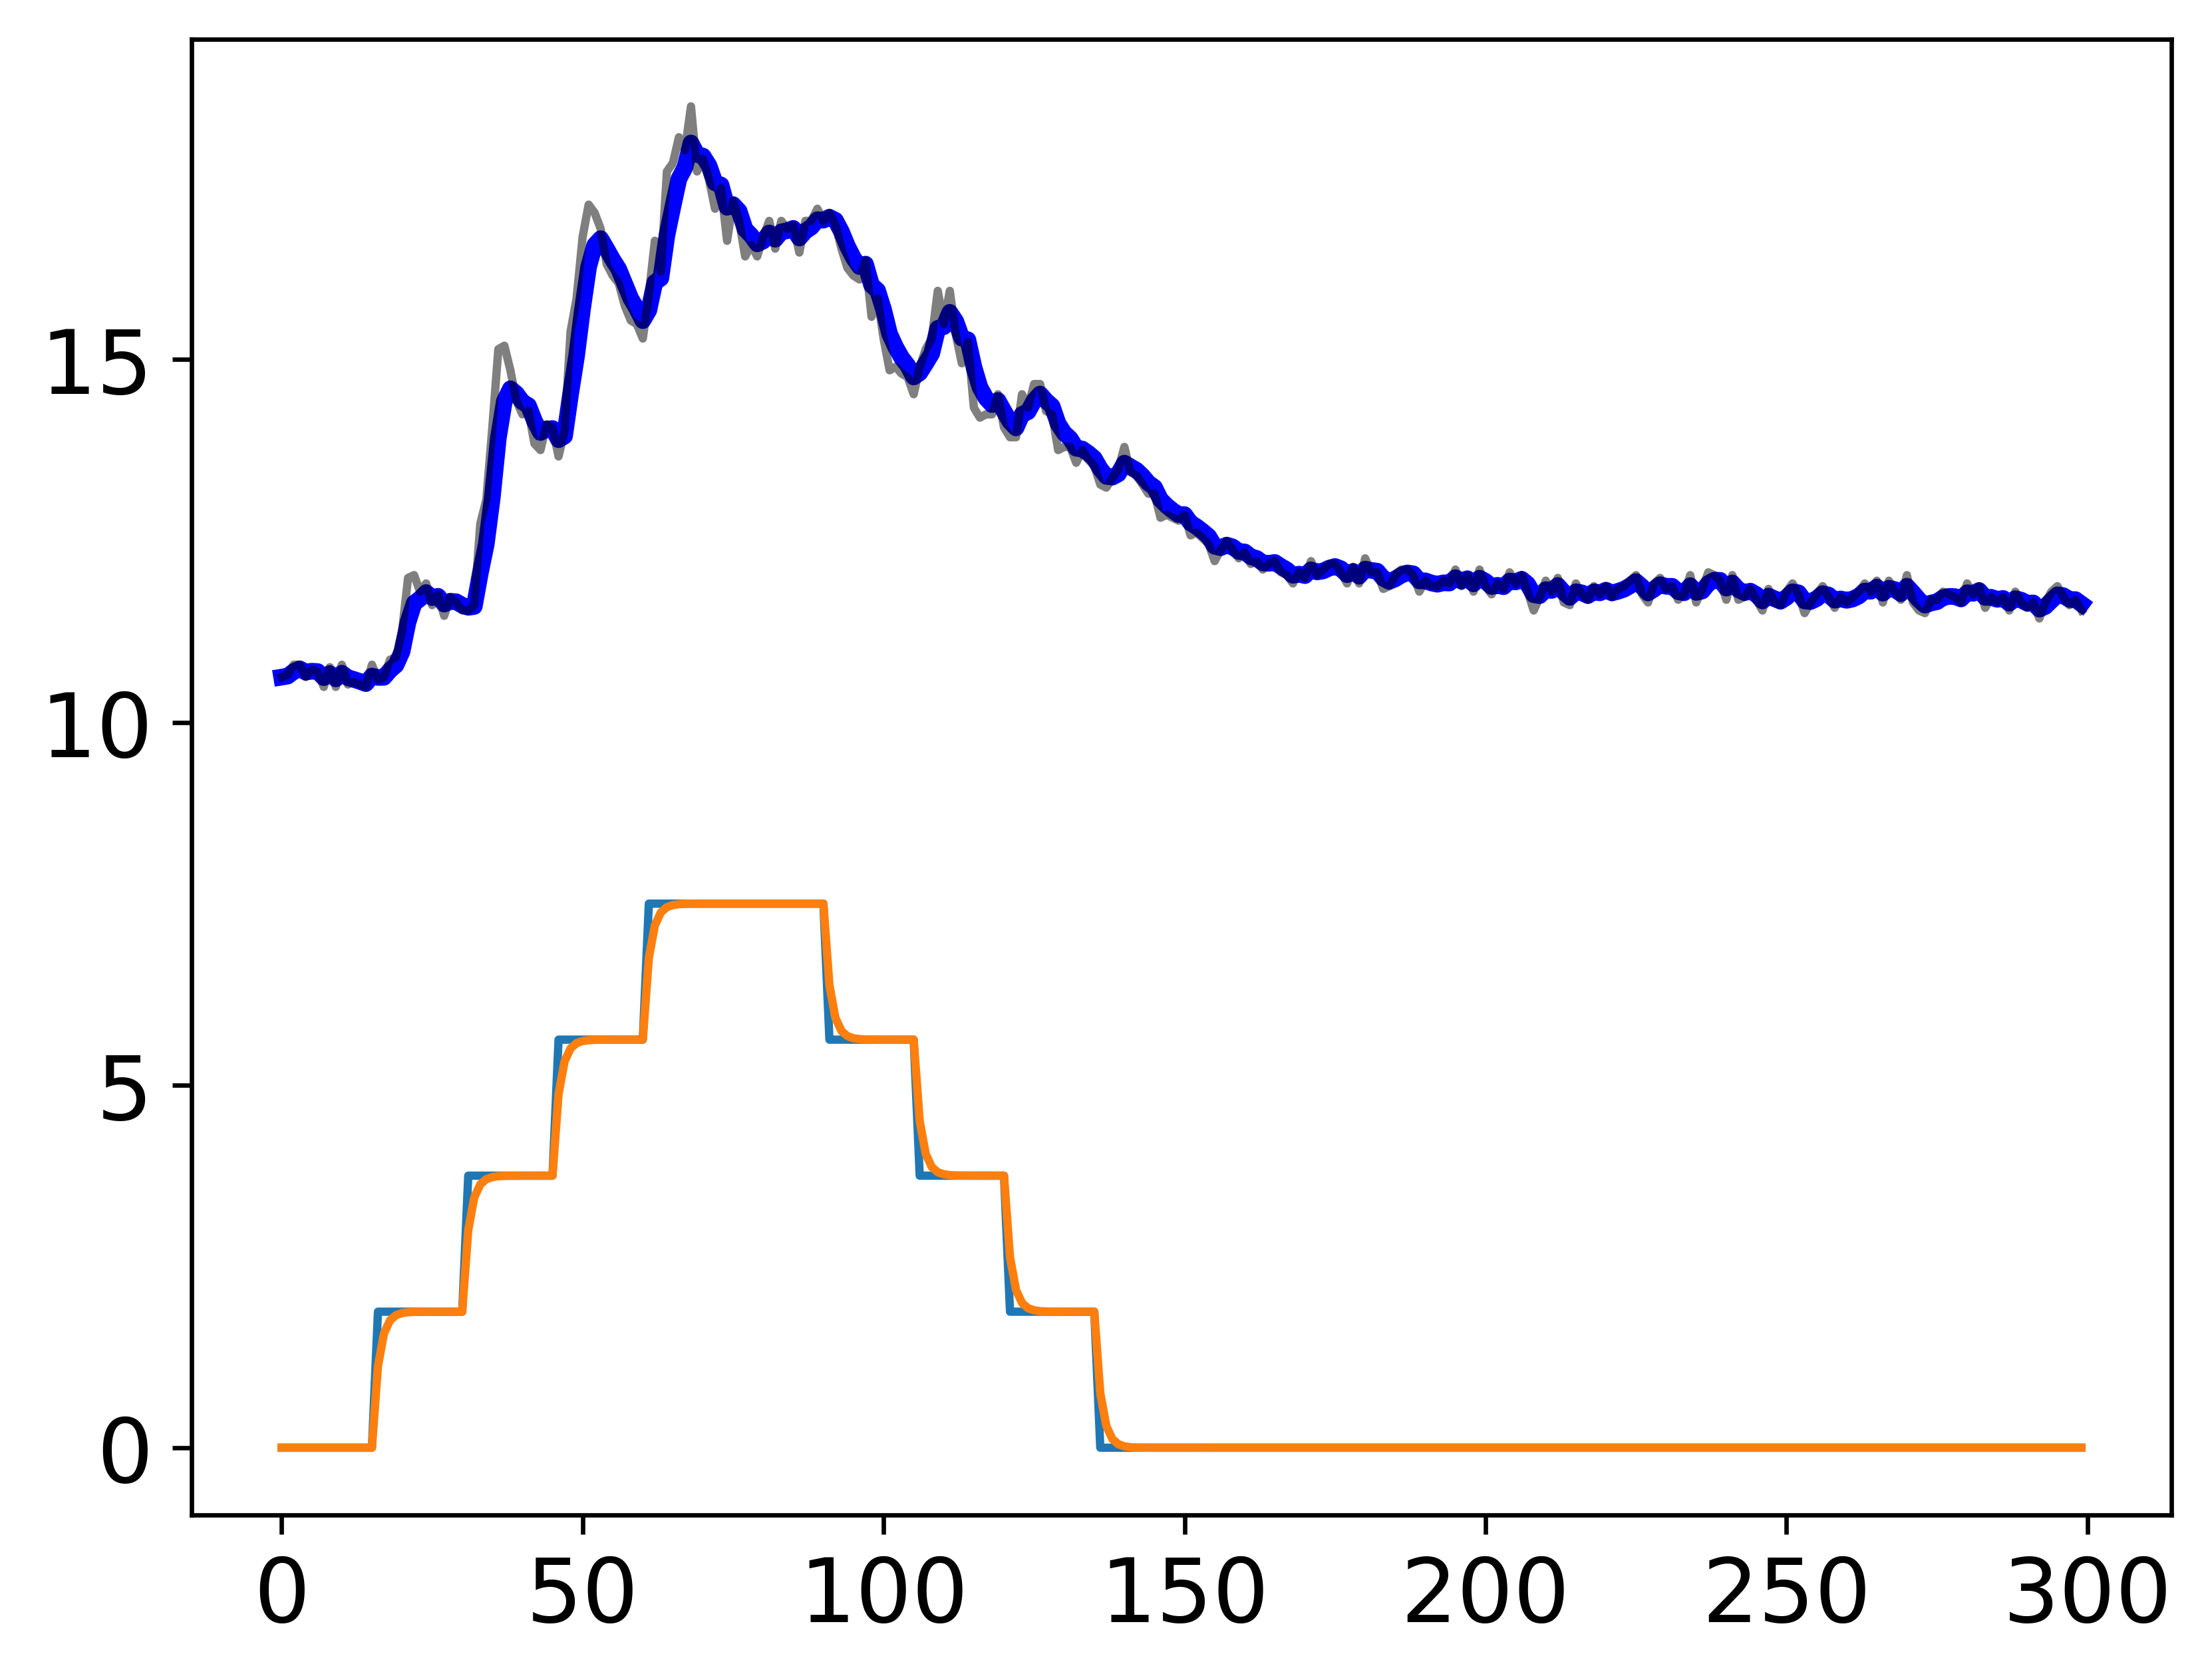

In [25]:
def exponential_moving_average(x, alpha):
    assert(type(alpha) == float or len(alpha) == x.shape[1]) 
    assert(np.all(alpha < 1))
    assert(np.all(alpha >  0))
    
    s = np.zeros_like(x)
    
    s[0,:] = x[0,:]
    for t in range(1, len(x), 1):
        s[t,:] = alpha * x[t,:] + (1 - alpha) * s[t-1,:]

    return s

s_tr_sensor = exponential_moving_average(tr_sensor, alpha=0.4)
s_vl_sensor = exponential_moving_average(vl_sensor, alpha=0.4)
s_tr_pressure = exponential_moving_average(tr_pressure, alpha=0.6)
s_tr_pressure = exponential_moving_average(tr_pressure, alpha=np.array([0.6,0.6,0.6]))

plt.figure(dpi=600)
plt.plot(s_tr_sensor[:300,0],linewidth=3, color='blue')
plt.plot(tr_sensor[:300,0], color='black', alpha=0.5)
plt.plot(tr_pressure[:300,0]/10)
plt.plot(s_tr_pressure[:300,0]/10)
#plt.plot(s_vl_sensor[:200,0],linewidth=3, color='orange')
#plt.plot(vl_sensor[:200,0], color='black', alpha=0.5)

In [8]:
pressures = [50, 100, 150, 200] # kPa

# Pulling datasets
pull_50_names = [
    data_dir_path + 'force_tests/pull_01_stiff-flop_1_1.csv',
    data_dir_path + 'force_tests/pull_01_stiff-flop_2_1.csv',
    data_dir_path + 'force_tests/pull_01_stiff-flop_3_1.csv']

pull_100_names = [
    data_dir_path + 'force_tests/pull_01_stiff-flop_4_1.csv',
    data_dir_path + 'force_tests/pull_01_stiff-flop_5_1.csv',
    data_dir_path + 'force_tests/pull_01_stiff-flop_6_1.csv']

pull_150_names = [
    data_dir_path + 'force_tests/pull_01_stiff-flop_7_1.csv',
    data_dir_path + 'force_tests/pull_01_stiff-flop_8_1.csv',
    data_dir_path + 'force_tests/pull_01_stiff-flop_9_1.csv']

pull_200_names = [
    data_dir_path + 'force_tests/pull_01_stiff-flop_10_1.csv',
    data_dir_path + 'force_tests/pull_01_stiff-flop_11_1.csv',
    data_dir_path + 'force_tests/pull_01_stiff-flop_12_1.csv']

# Pushing datasets
push_50_names = [data_dir_path + 'force_tests/push01_stiff-flop_1_1.csv',
                 data_dir_path + 'force_tests/push01_stiff-flop_2_1.csv',
                 data_dir_path + 'force_tests/push01_stiff-flop_3_1.csv',
                 ]

push_100_names = [data_dir_path + 'force_tests/push01_stiff-flop_4_1.csv',
                 data_dir_path + 'force_tests/push01_stiff-flop_5_1.csv',
                 data_dir_path + 'force_tests/push01_stiff-flop_6_1.csv']

push_150_names = [data_dir_path + 'force_tests/push01_stiff-flop_7_1.csv',
                 data_dir_path + 'force_tests/push01_stiff-flop_8_1.csv',
                 data_dir_path + 'force_tests/push01_stiff-flop_9_1.csv']

push_200_names = [data_dir_path + 'force_tests/push01_stiff-flop_10_1.csv',
                 data_dir_path + 'force_tests/push01_stiff-flop_11_1.csv',
                 data_dir_path + 'force_tests/push01_stiff-flop_12_1.csv']

In [9]:
# Pull dataframes
pull_50_dfs = [pd.read_csv(name).iloc[1:] for name in pull_50_names] # remove first row
pull_100_dfs = [pd.read_csv(name).iloc[1:] for name in pull_100_names] # remove first row
pull_150_dfs = [pd.read_csv(name).iloc[1:] for name in pull_150_names] # remove first row
pull_200_dfs = [pd.read_csv(name).iloc[1:] for name in pull_200_names] # remove first row

# Push dataframes
push_50_dfs = [pd.read_csv(name).iloc[1:] for name in push_50_names] # remove first row
push_100_dfs = [pd.read_csv(name).iloc[1:] for name in push_100_names] # remove first row
push_150_dfs = [pd.read_csv(name).iloc[1:] for name in push_150_names] # remove first row
push_200_dfs = [pd.read_csv(name).iloc[1:] for name in push_200_names] # remove first row

In [10]:
# Extract maximum force from the time series of each trial, then average the maximum values

# Pull
max_pull_forces_50 = [df['Force'].to_numpy(dtype=np.float32).min() for df in pull_50_dfs]
max_pull_forces_100 = [df['Force'].to_numpy(dtype=np.float32).min() for df in pull_100_dfs]
max_pull_forces_150 = [df['Force'].to_numpy(dtype=np.float32).min() for df in pull_150_dfs]
max_pull_forces_200 = [df['Force'].to_numpy(dtype=np.float32).min() for df in pull_200_dfs]

mean_pull_forces = [np.abs(np.mean(max_pull_forces_50)),
                    np.abs(np.mean(max_pull_forces_100)),
                    np.abs(np.mean(max_pull_forces_150)),
                    np.abs(np.mean(max_pull_forces_200))]
                    

std_pull_forces = [np.std(max_pull_forces_50), 
                   np.std(max_pull_forces_100),
                   np.std(max_pull_forces_150),
                   np.std(max_pull_forces_200)]

# Push
max_push_forces_50 = [df['Force'].to_numpy(dtype=np.float32).max() for df in push_50_dfs]
max_push_forces_100 = [df['Force'].to_numpy(dtype=np.float32).max() for df in push_100_dfs]
max_push_forces_150 = [df['Force'].to_numpy(dtype=np.float32).max() for df in push_150_dfs]
max_push_forces_200 = [df['Force'].to_numpy(dtype=np.float32).max() for df in push_200_dfs]

mean_push_forces = [np.abs(np.mean(max_push_forces_50)),
                    np.abs(np.mean(max_push_forces_100)),
                    np.abs(np.mean(max_push_forces_150)),
                    np.abs(np.mean(max_push_forces_200))]
                    
std_push_forces = [np.std(max_push_forces_50), 
                   np.std(max_push_forces_100),
                   np.std(max_push_forces_150),
                   np.std(max_push_forces_200)]

# TODO: flippa ora ma fixa
mean_push_forces = np.flip(mean_push_forces)
std_push_forces = np.flip(std_push_forces)

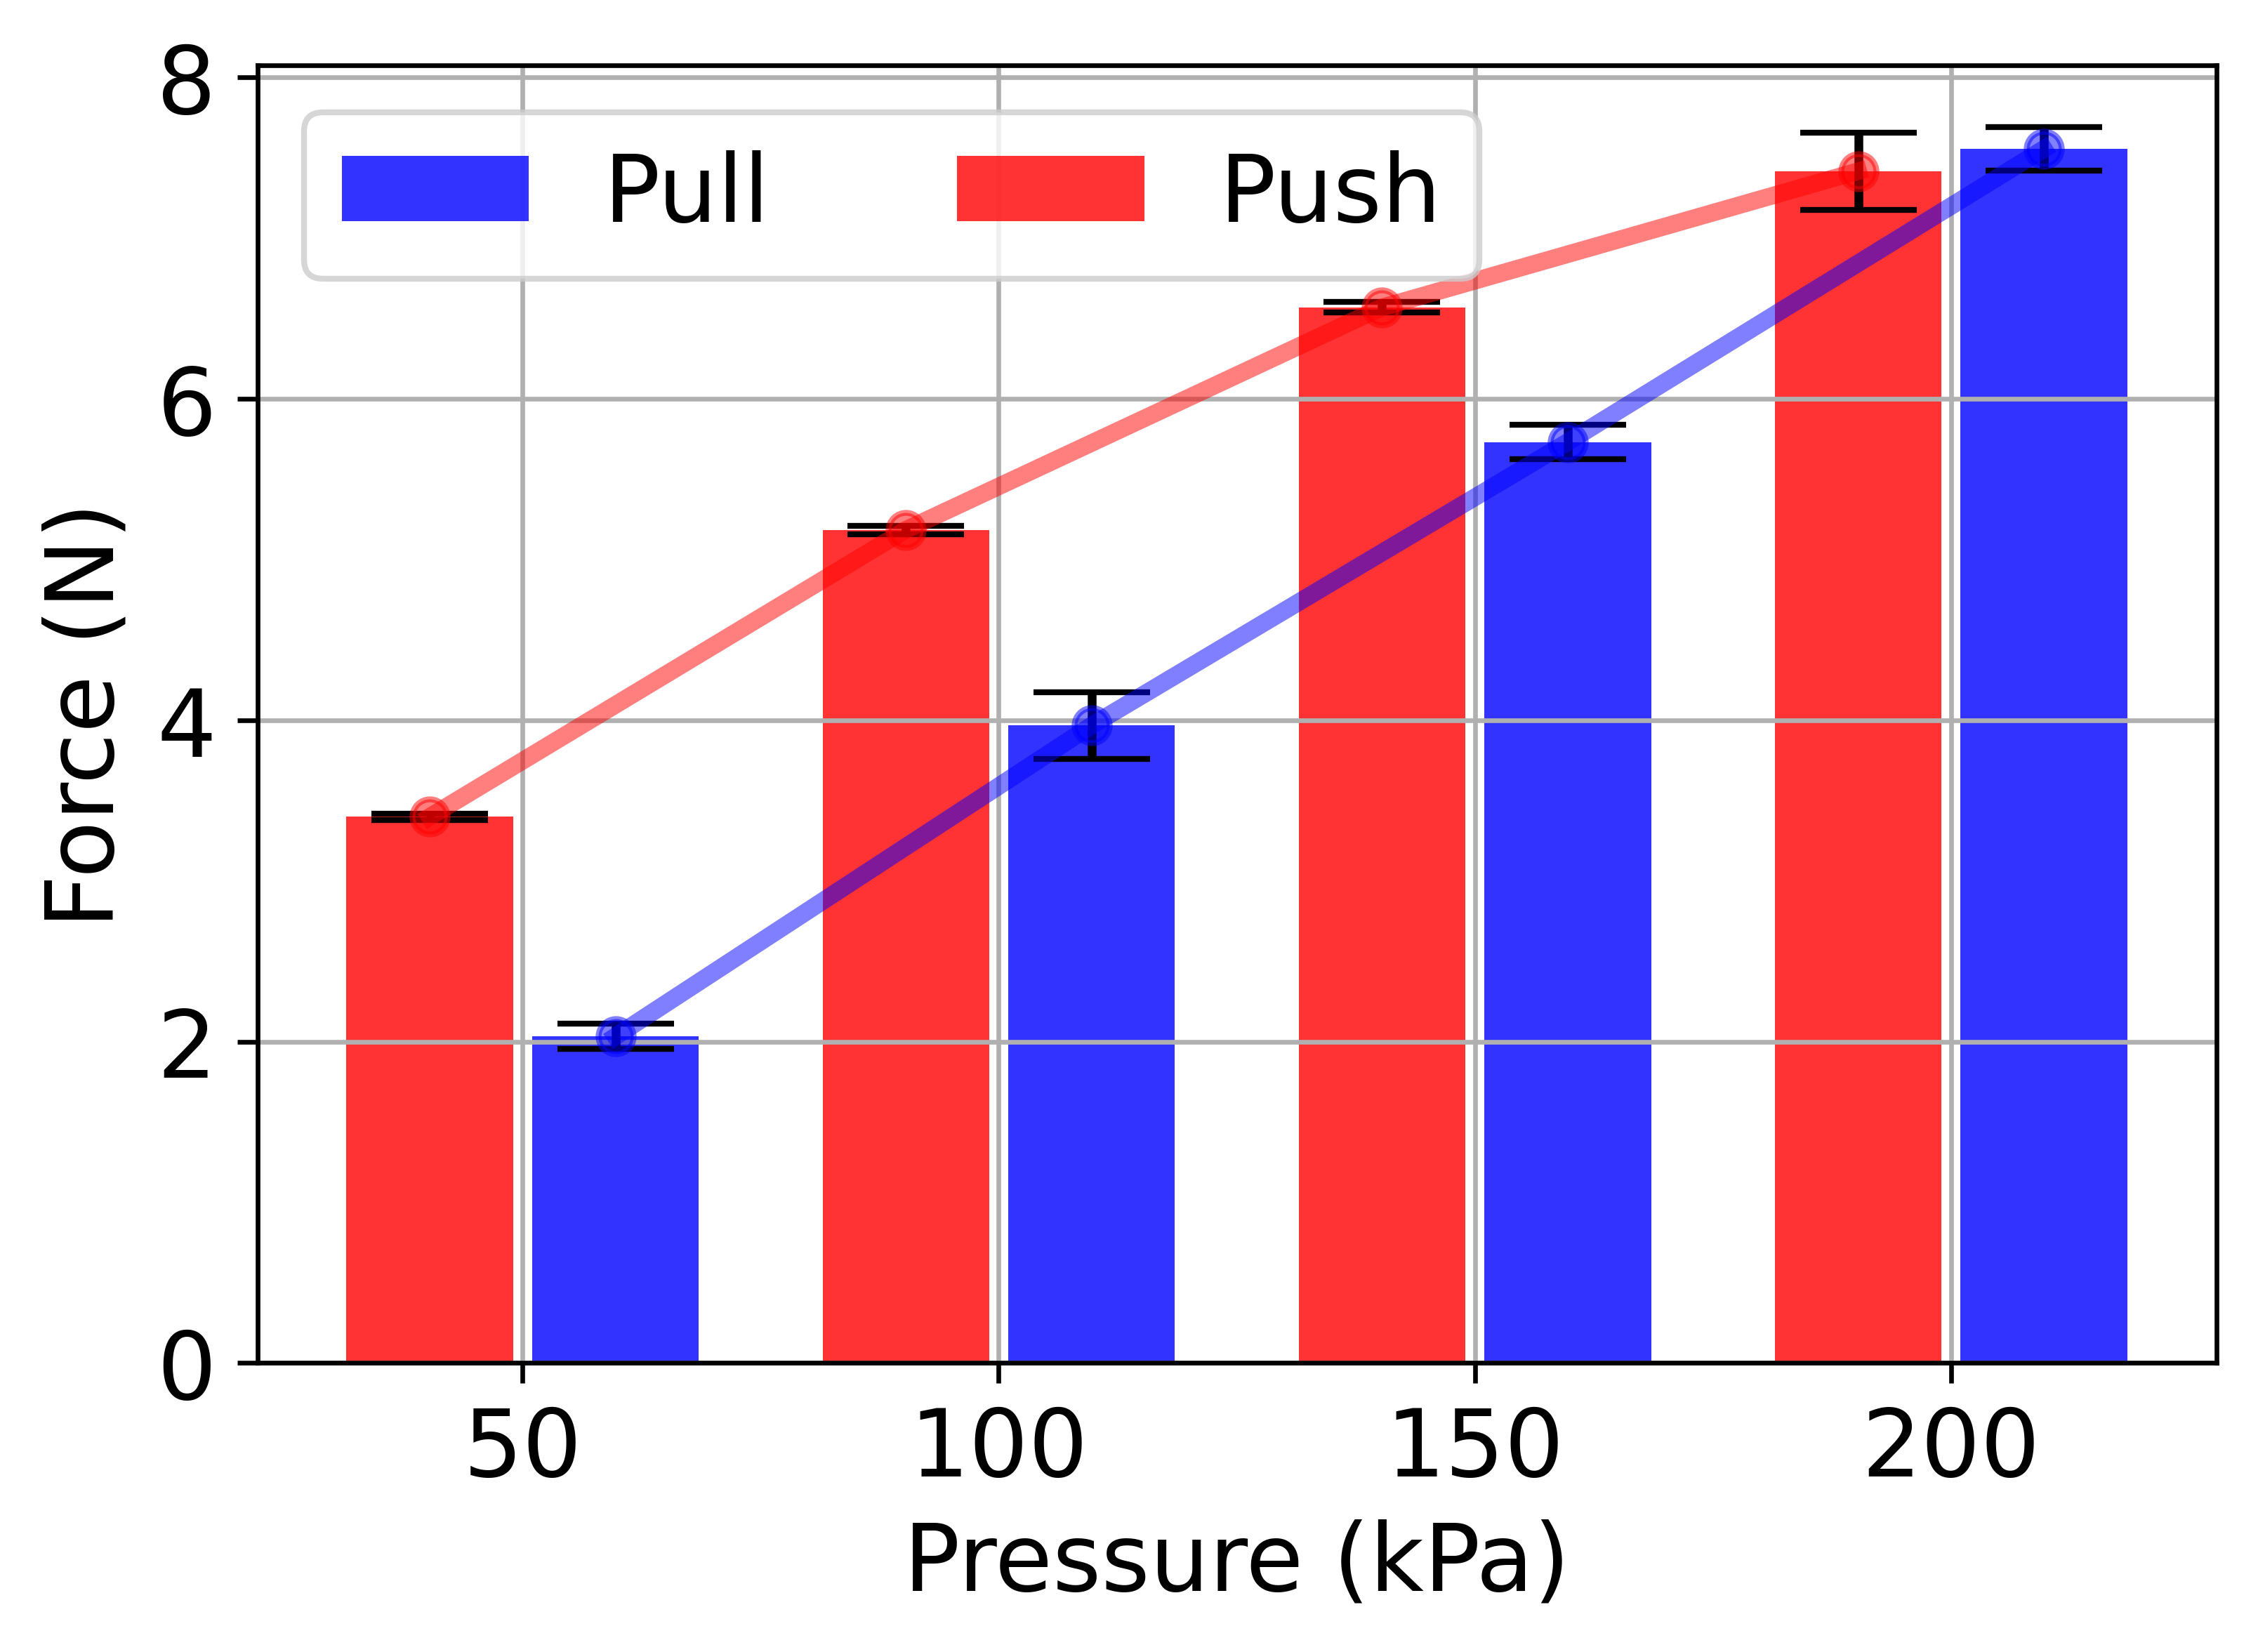

In [11]:
bar_w = 0.35
x_pull = np.arange(len(pressures)) + bar_w/2 + 0.02
x_push = np.arange(len(pressures)) - bar_w/2 - 0.02

fig = plt.figure(figsize=(6,4), dpi=600)
plt.bar(x=x_pull, height=mean_pull_forces, yerr=std_pull_forces, width=bar_w, label='Pull',
        color='blue', ecolor='black', linewidth=3, capsize=10, alpha=0.8)
plt.plot(x_pull, mean_pull_forces, 'o-', linewidth=3, alpha=0.5, color='blue')

# TODO fix flip
plt.bar(x=x_push, height=mean_push_forces, yerr=std_push_forces, width=bar_w, label='Push',
        color='red', ecolor='black', linewidth=3, capsize=10, alpha=0.8)
plt.plot(x_push, mean_push_forces, 'o-', linewidth=3, alpha=0.5, color='red')

plt.xticks([0,1,2,3], pressures)
plt.ylabel('Force (N)')
plt.xlabel('Pressure (kPa)')
plt.grid()
plt.legend(loc='best', ncols=2)
#fig.savefig('../figures/textile_stiff-flop_force_tests.pdf', bbox_inches='tight')
#fig.savefig('../figures/textile_stiff-flop_force_tests.png', bbox_inches='tight')
plt.show()

In [20]:
for i, p in enumerate(pressures):
    print("Pressure %d (kPa) - Pull force: %.2f +- %.2f (N)" % (p, mean_pull_forces[i], std_pull_forces[i]))

print()

for i, p in enumerate(pressures):
    print("Pressure %d (kPa) - Push force: %.2f +- %.2f (N)" % (p, mean_push_forces[i], std_push_forces[i]))

Pressure 50 (kPa) - Pull force: 2.03 +- 0.08 (N)
Pressure 100 (kPa) - Pull force: 3.97 +- 0.21 (N)
Pressure 150 (kPa) - Pull force: 5.73 +- 0.11 (N)
Pressure 200 (kPa) - Pull force: 7.55 +- 0.13 (N)

Pressure 50 (kPa) - Push force: 3.40 +- 0.02 (N)
Pressure 100 (kPa) - Push force: 5.18 +- 0.03 (N)
Pressure 150 (kPa) - Push force: 6.57 +- 0.03 (N)
Pressure 200 (kPa) - Push force: 7.42 +- 0.24 (N)


## Workspace Characterization

In [7]:
ws_data_df = pd.read_excel(data_dir_path + 'workspace_characterization/workspace.xlsx')
ws_data_df.columns

Index(['p [KPa]', 'dl1 [mm]', 'dl2 [mm]', 'dl3  [mm]', 'edl1 [mm]',
       'edl2 [mm]', 'edl3  [mm]', 'thetacl1 [°]', 'thetacl2 [°]',
       'thetacl3 [°]', 'dtheta1 [°]', 'dtheta2 [°]', 'dtheta3 [°]',
       'theta_acl1 [°]', 'thetacl2 [°].1', 'thetacl3 [°].1', 'dtheta1 [°].1',
       'dtheta2 [°].1', 'dtheta3 [°].1'],
      dtype='object')

In [8]:
pressures = ws_data_df['p [KPa]'].to_numpy()

delta_ls = ws_data_df[['dl1 [mm]', 'dl2 [mm]', 'dl3  [mm]']].to_numpy()
error_delta_ls = ws_data_df[['edl1 [mm]', 'edl2 [mm]', 'edl3  [mm]']].to_numpy()

theta_1 = ws_data_df[['thetacl1 [°]', 'thetacl2 [°]', 'thetacl3 [°]']].to_numpy()
error_theta_1 = ws_data_df[['dtheta1 [°]', 'dtheta2 [°]', 'dtheta3 [°]']].to_numpy()

theta_2 = ws_data_df[['theta_acl1 [°]', 'thetacl2 [°].1', 'thetacl3 [°].1']].to_numpy()
error_theta_2 = ws_data_df[['dtheta1 [°].1', 'dtheta2 [°].1', 'dtheta3 [°].1']].to_numpy()

pressures.shape, delta_ls.shape, error_delta_ls.shape

((11,), (11, 3), (11, 3))

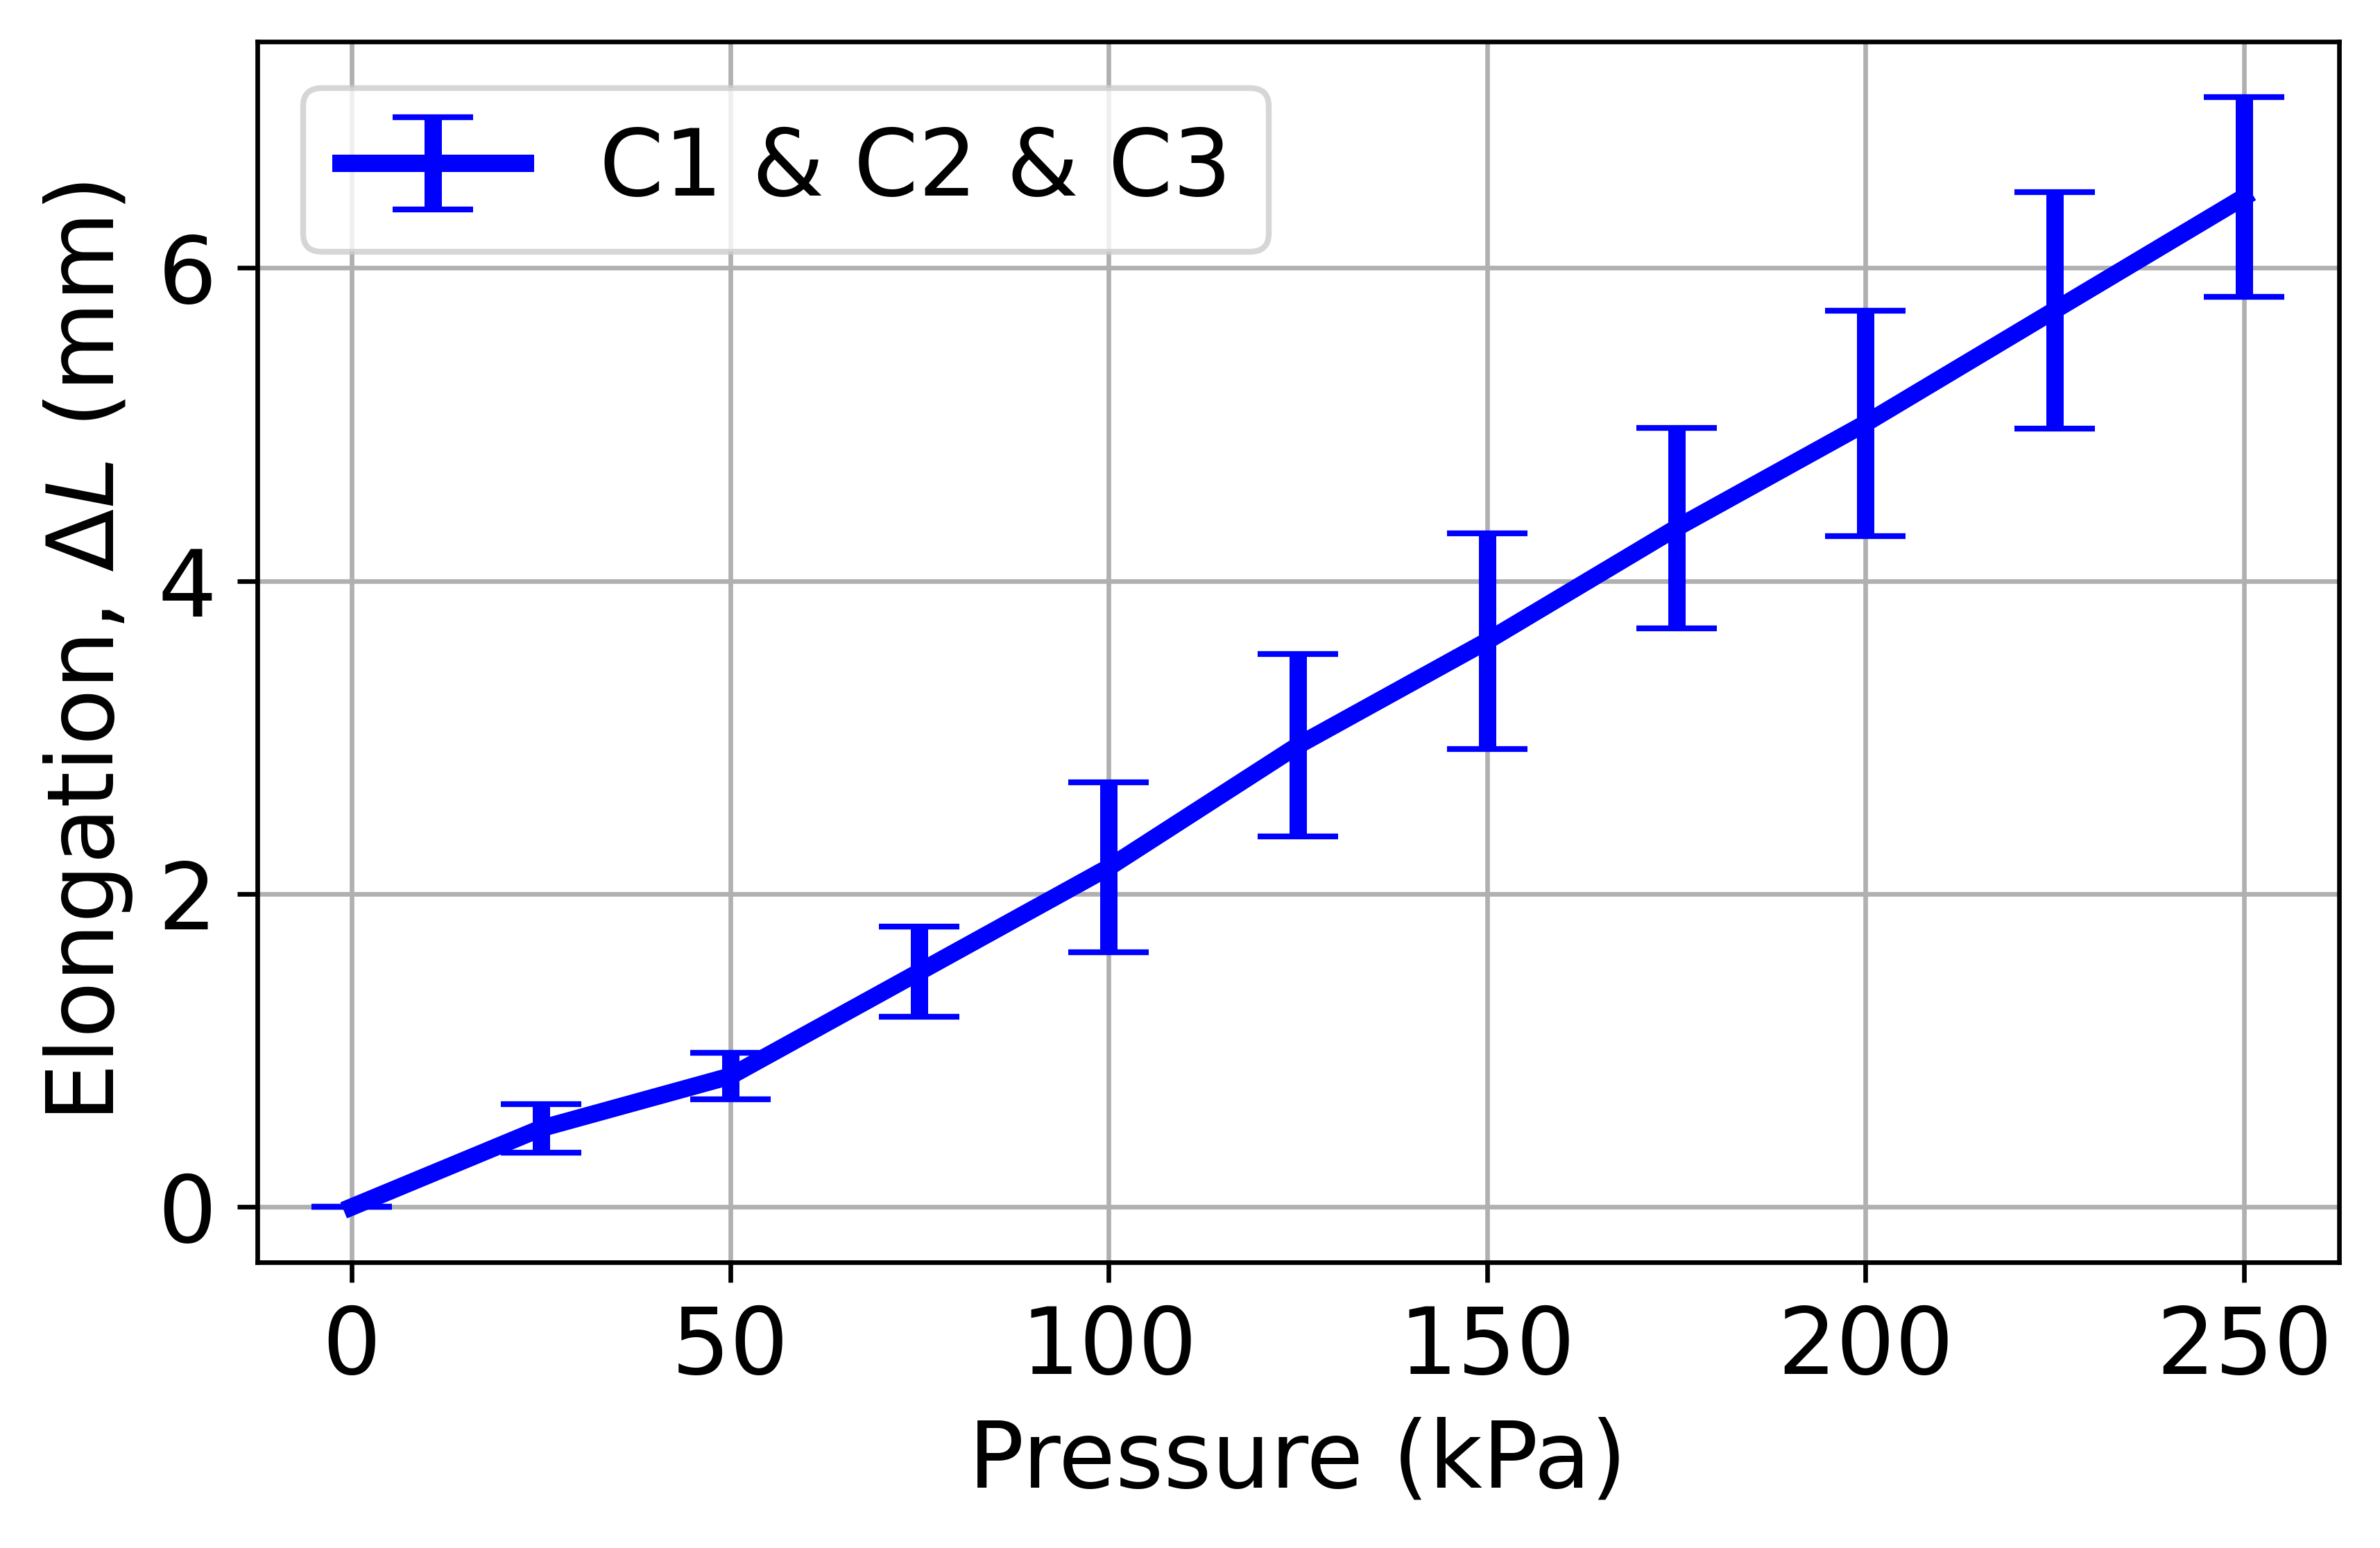

In [12]:
# elongation
fig = plt.figure(figsize=(6,4), dpi=600)
#plt.errorbar(x=pressures, y=delta_ls[:,0], yerr=error_delta_ls[:,0], capsize=7, linewidth=3, label='C1', alpha=0.7)
#plt.errorbar(x=pressures, y=delta_ls[:,1], yerr=error_delta_ls[:,1], capsize=7, linewidth=3, label='C2', alpha=0.7)
#plt.errorbar(x=pressures, y=delta_ls[:,2], yerr=error_delta_ls[:,2], capsize=7, linewidth=3, label='C3', alpha=0.7)
plt.errorbar(x=pressures, y=np.mean(delta_ls, axis=1), yerr=np.mean(error_delta_ls, axis=1), capsize=7, linewidth=3, label='C1 & C2 & C3', color='blue')

plt.xlabel('Pressure (kPa)')
plt.ylabel('Elongation, $\Delta L$ (mm)')

plt.legend(loc='best')
plt.grid()
plt.tight_layout()
fig.savefig('../figures/textile_stiff-flop_elongation.pdf', bbox_inches='tight')
fig.savefig('../figures/textile_stiff-flop_elongation.png', bbox_inches='tight')
fig.savefig('../figures/textile_stiff-flop_elongation.svg', bbox_inches='tight')
plt.show()

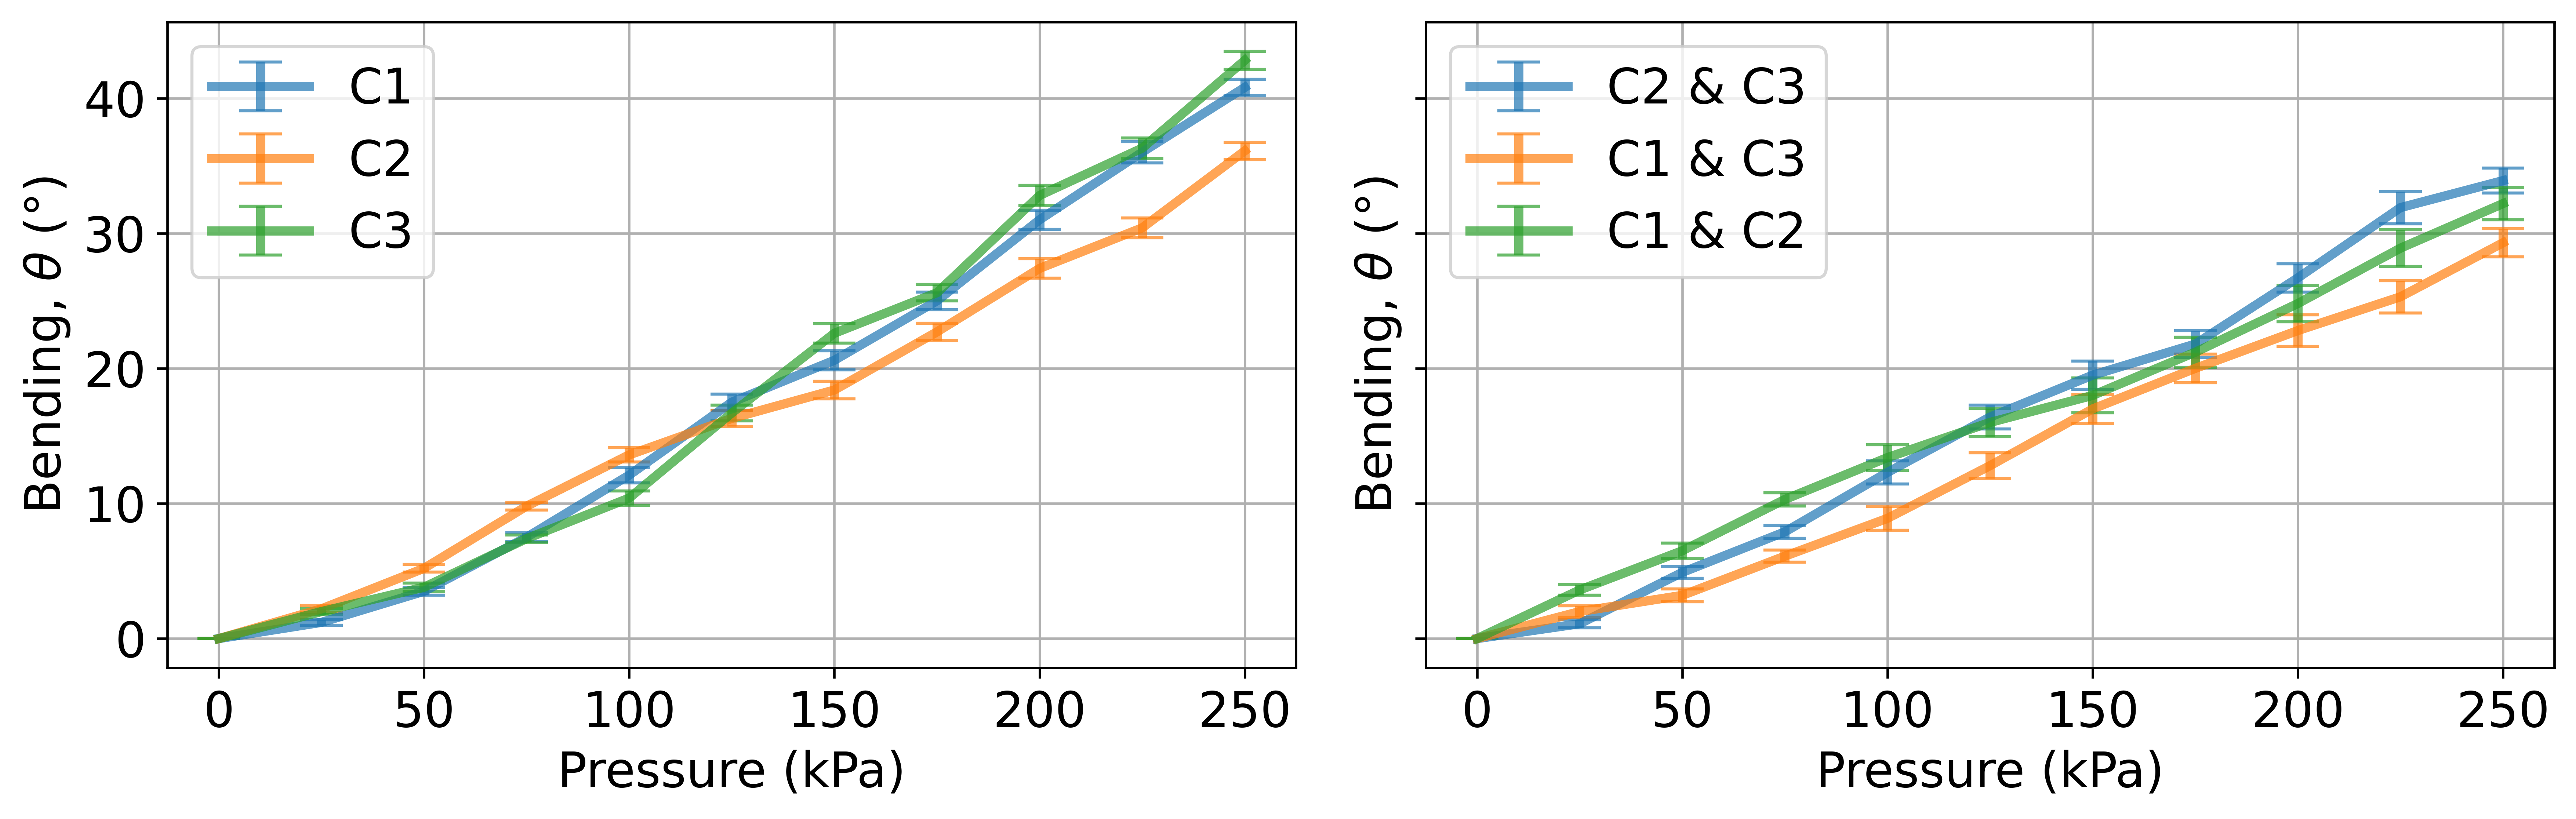

In [11]:
# Bending theta_r e theta_l

# theta_r
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,4), dpi=600, sharey=True)
ax1.errorbar(x=pressures, y=theta_1[:,0], yerr=error_theta_1[:,0], capsize=7, linewidth=3, label='C1', alpha=0.7)
ax1.errorbar(x=pressures, y=theta_1[:,1], yerr=error_theta_1[:,1], capsize=7, linewidth=3, label='C2', alpha=0.7)
ax1.errorbar(x=pressures, y=theta_1[:,2], yerr=error_theta_1[:,2], capsize=7, linewidth=3, label='C3', alpha=0.7)
ax1.set_xlabel('Pressure (kPa)')
ax1.set_ylabel(r'Bending, $\theta$ ($\degree$)')
ax1.grid()

ax2.errorbar(x=pressures, y=theta_2[:,0], yerr=error_theta_2[:,0], capsize=7, linewidth=3, label='C2 & C3', alpha=0.7)
ax2.errorbar(x=pressures, y=theta_2[:,1], yerr=error_theta_2[:,1], capsize=7, linewidth=3, label='C1 & C3', alpha=0.7)
ax2.errorbar(x=pressures, y=theta_2[:,2], yerr=error_theta_2[:,2], capsize=7, linewidth=3, label='C1 & C2', alpha=0.7)
ax2.set_xlabel('Pressure (kPa)')
ax2.set_ylabel(r'Bending, $\theta$ ($\degree$)')
ax2.grid()

ax1.legend(loc='best')
ax2.legend(loc='best')
plt.tight_layout()
fig.savefig('../figures/textile_stiff-flop_bending.pdf', bbox_inches='tight')
fig.savefig('../figures/textile_stiff-flop_bending.png', bbox_inches='tight')
fig.savefig('../figures/textile_stiff-flop_bending.svg', bbox_inches='tight')
plt.show()

In [91]:
print("Elongation")
for p, dl, err_dl in zip(pressures, delta_ls, error_delta_ls):
    print('Pressure %d kPa - delta_l (%.1f, %.1f, %.1f) +- (%.1f, %.1f, %.1f) mm' % (p, *dl, *err_dl))

Elongation
Pressure 0 kPa - delta_l (0.0, 0.0, 0.0) +- (0.0, 0.0, 0.0) mm
Pressure 25 kPa - delta_l (0.3, 0.5, 0.7) +- (0.1, 0.2, 0.2) mm
Pressure 50 kPa - delta_l (0.7, 0.7, 1.2) +- (0.2, 0.1, 0.1) mm
Pressure 75 kPa - delta_l (1.3, 1.7, 1.5) +- (0.3, 0.3, 0.3) mm
Pressure 100 kPa - delta_l (2.0, 2.3, 2.2) +- (0.6, 0.5, 0.5) mm
Pressure 125 kPa - delta_l (2.6, 3.0, 3.2) +- (0.6, 0.6, 0.6) mm
Pressure 150 kPa - delta_l (3.3, 3.5, 4.0) +- (0.7, 0.6, 0.7) mm
Pressure 175 kPa - delta_l (4.1, 4.2, 4.7) +- (0.7, 0.6, 0.6) mm
Pressure 200 kPa - delta_l (4.6, 4.9, 5.6) +- (0.7, 0.7, 0.7) mm
Pressure 225 kPa - delta_l (5.3, 5.5, 6.4) +- (0.8, 0.7, 0.8) mm
Pressure 250 kPa - delta_l (6.1, 6.2, 7.1) +- (0.6, 0.6, 0.7) mm


In [92]:
print("\nBending theta_r")
for p, theta_r, err_theta_r in zip(pressures, theta_1, error_theta_1):
    print('Pressure %d kPa - theta_r (%.1f, %.1f, %.1f) +- (%.1f, %.1f, %.1f) deg' % (p, *theta_r, *err_theta_r))


print("\nBending theta_l")
for p, theta_l, err_theta_l in zip(pressures, theta_2, error_theta_2):
    print('Pressure %d kPa - theta_l (%.1f, %.1f, %.1f) +- (%.1f, %.1f, %.1f) deg' % (p, *theta_l, *err_theta_l))


Bending theta_r
Pressure 0 kPa - theta_r (0.0, 0.0, 0.0) +- (0.0, 0.0, 0.0) deg
Pressure 25 kPa - theta_r (1.2, 2.2, 2.0) +- (0.2, 0.3, 0.2) deg
Pressure 50 kPa - theta_r (3.5, 5.2, 3.8) +- (0.3, 0.3, 0.3) deg
Pressure 75 kPa - theta_r (7.5, 9.8, 7.4) +- (0.3, 0.3, 0.3) deg
Pressure 100 kPa - theta_r (12.1, 13.6, 10.4) +- (0.6, 0.5, 0.5) deg
Pressure 125 kPa - theta_r (17.5, 16.3, 16.7) +- (0.6, 0.6, 0.6) deg
Pressure 150 kPa - theta_r (20.6, 18.4, 22.6) +- (0.7, 0.6, 0.7) deg
Pressure 175 kPa - theta_r (25.0, 22.7, 25.6) +- (0.7, 0.6, 0.6) deg
Pressure 200 kPa - theta_r (31.0, 27.4, 32.8) +- (0.7, 0.7, 0.7) deg
Pressure 225 kPa - theta_r (36.0, 30.4, 36.3) +- (0.8, 0.7, 0.8) deg
Pressure 250 kPa - theta_r (40.8, 36.1, 42.8) +- (0.6, 0.6, 0.7) deg

Bending theta_l
Pressure 0 kPa - theta_l (0.0, 0.0, 0.0) +- (0.0, 0.0, 0.0) deg
Pressure 25 kPa - theta_l (1.1, 2.0, 3.6) +- (0.3, 0.4, 0.4) deg
Pressure 50 kPa - theta_l (4.9, 3.2, 6.5) +- (0.4, 0.5, 0.6) deg
Pressure 75 kPa - theta_l (7.9

In [16]:
# save arrays for nicco
np.savez(file="./soft-tex-push-pull-deltal.npz",
         pressures=pressures, 
         mean_push_forces=mean_push_forces, 
         std_push_forces=std_push_forces, 
         mean_pull_forces=mean_pull_forces, 
         std_pull_forces=std_pull_forces,
         delta_l_mean=np.mean(delta_ls, axis=1), 
         delta_l_std=np.mean(error_delta_ls, axis=1)
        )

results = np.load("soft-tex-push-pull.npz")
results['mean_push_forces'], results['delta_l_mean'], results['delta_l_std']

(array([3.3984   , 5.184467 , 6.5686665, 7.4158998], dtype=float32),
 array([0.        , 0.502     , 0.83566667, 1.50233333, 2.16966667,
        2.949     , 3.61666667, 4.339     , 5.00766667, 5.731     ,
        6.45333333]),
 array([0.        , 0.15673333, 0.1488    , 0.28776667, 0.54376667,
        0.58266667, 0.6899    , 0.64073333, 0.72093333, 0.7554    ,
        0.6388    ]))